#### MODEL BASE CONTENT FILTERING

#### UCITALI DS

In [ ]:
import pandas as pd
import os
import h5py

df_ceo = pd.read_csv(r'C:\Users\Lena\Downloads\millionsongsubset\mergeovan.csv')
df= df_ceo[['user_id', 'song_id', 'play_count', 'artist_id', 'artist_terms', 'loudness', 'tempo', 'time_signature', 'similar_artists']]

df.sample(0)

,user_id,song_id,play_count,artist_id,artist_terms,loudness,tempo,time_signature,similar_artists


In [ ]:
#prazna polja

numericke_kolone = ['loudness', 'tempo', 'time_signature','play_count']
print("--- BROJ PRAZNIH POLJA PO KOLONAMA ---")
print(df[numericke_kolone].isna().sum())
print("-" * 40)

for kolona in numericke_kolone:
    prazni_redovi = df[df[kolona].isna()].index.tolist()
    
    if len(prazni_redovi) > 0:
        print(f"Kolona '{kolona}' ima prazna polja u ")
        if len(prazni_redovi) > 20:
            print(f"  {prazni_redovi[:20]} {len(prazni_redovi) - 20} redova)")
        else:
            print(f"  {prazni_redovi}")
    else:
        print(f"Kolona '{kolona}' nema")
print(len(df))

--- BROJ PRAZNIH POLJA PO KOLONAMA ---


NameError: name 'df' is not defined

In [ ]:
from scipy.sparse import hstack, csr_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import MinMaxScaler

df['artist_terms'] = df['artist_terms'].fillna('unknown')

df['terms_clean_text'] = df['artist_terms'].astype(str).str.lower()
df['terms_clean_text'] = df['terms_clean_text'].str.replace(r"[\[\]'\"]", "", regex=True)

df['terms_clean_text'] = df['terms_clean_text'].apply(lambda x: 'unknown' if x.strip() == '' else x)


tfidf = TfidfVectorizer(max_features=1000)
tfidf_matrica = tfidf.fit_transform(df['terms_clean_text'])

print(f"pesme x karakteristike {tfidf_matrica.shape}") 

C:\Users\Lena\AppData\Local\Temp\ipykernel_28324\2037538810.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['artist_terms'] = df['artist_terms'].fillna('unknown')



--- TF-IDF USPEŠNO ZAVRŠEN ---
Oblik TF-IDF matrice (Pesme x Karakteristike): (271831, 475)


In [ ]:
df['similar_artists'] = df['similar_artists'].fillna('unknown')

df['artists_clean_text'] = df['similar_artists'].astype(str).str.lower()
df['artists_clean_text'] = df['artists_clean_text'].str.replace(r"[\[\]'\"]", "", regex=True)

df['artists_clean_text'] = df['artists_clean_text'].apply(lambda x: 'unknown' if x.strip() == '' else x)

tfidf = TfidfVectorizer(max_features=1000)
tfidf_matrica = tfidf.fit_transform(df['artists_clean_text'])

print(f"pesme x karakteristike {tfidf_matrica.shape}") 


--- TF-IDF USPEŠNO ZAVRŠEN ---
Oblik TF-IDF matrice (Pesme x Karakteristike): (271831, 1000)


#### delimo na test i train set

In [ ]:
numericke_kolone = ['loudness', 'tempo', 'time_signature', 'play_count', 'terms_clean_text', 'artists_clean_text']
print(df[numericke_kolone].isna().sum())
print("-" * 40)

for kolona in numericke_kolone:
    prazni_redovi = df[df[kolona].isna()].index.tolist()
    
    if len(prazni_redovi) > 0:
        print(f"kolons '{kolona}' ima prazno ")
        if len(prazni_redovi) > 20:
            print(f"  {prazni_redovi[:20]} {len(prazni_redovi) - 20} redova)")
        else:
            print(f"  {prazni_redovi}")
    else:
        print(f"kolomns '{kolona}' nema")

--- BROJ PRAZNIH POLJA PO KOLONAMA ---
loudness              0
tempo                 0
time_signature        0
play_count            0
terms_clean_text      0
artists_clean_text    0
dtype: int64
----------------------------------------

--- LOKACIJE PRAZNIH POLJA (INDEKSI REDOVA) ---
Kolona 'loudness' nema praznih polja.
Kolona 'tempo' nema praznih polja.
Kolona 'time_signature' nema praznih polja.
Kolona 'play_count' nema praznih polja.
Kolona 'terms_clean_text' nema praznih polja.
Kolona 'artists_clean_text' nema praznih polja.


In [7]:
print(df.columns.tolist())

['user_id', 'song_id', 'play_count', 'artist_id', 'artist_terms', 'loudness', 'tempo', 'time_signature', 'similar_artists', 'terms_clean_text', 'artists_clean_text']


## DECISION TREE

In [8]:
from sklearn import tree
from sklearn.model_selection import train_test_split
from scipy.sparse import hstack
clf = tree.DecisionTreeRegressor()

le = LabelEncoder()
y = le.fit_transform(df['song_id'])

x_priv=df[['loudness', 'tempo', 'time_signature', 'play_count']]
x = hstack([x_priv, tfidf_matrica])


x, x_test, y, y_test = train_test_split(x, y, test_size=0.15, random_state=42)

x_train, x_val, y_train, y_val = train_test_split(
    x, y, test_size=0.1765, random_state=42
)

clf= clf.fit(x_train, y_train)

[Text(0.7498475423727592, 0.9918032786885246, 'x[1] <= 0.45\nsquared_error = 490040.932\nsamples = 190274\nvalue = 1459.029'),
 Text(0.5215438876643557, 0.9754098360655737, 'x[6] <= 0.044\nsquared_error = 544302.876\nsamples = 74512\nvalue = 1188.922'),
 Text(0.6356957150185574, 0.9836065573770492, 'True  '),
 Text(0.5066786559175186, 0.9590163934426229, 'x[163] <= 0.042\nsquared_error = 489140.76\nsamples = 63574\nvalue = 1069.605'),
 Text(0.4948020941499907, 0.9426229508196722, 'x[828] <= 0.058\nsquared_error = 508588.142\nsamples = 51811\nvalue = 1192.764'),
 Text(0.4787006427832835, 0.9262295081967213, 'x[676] <= 0.037\nsquared_error = 477508.605\nsamples = 45881\nvalue = 1297.642'),
 Text(0.4600475761813194, 0.9098360655737705, 'x[199] <= 0.058\nsquared_error = 486834.371\nsamples = 32928\nvalue = 1451.059'),
 Text(0.44362413160350894, 0.8934426229508197, 'x[479] <= 0.137\nsquared_error = 497941.754\nsamples = 28867\nvalue = 1377.622'),
 Text(0.4266385212135269, 0.8770491803278688

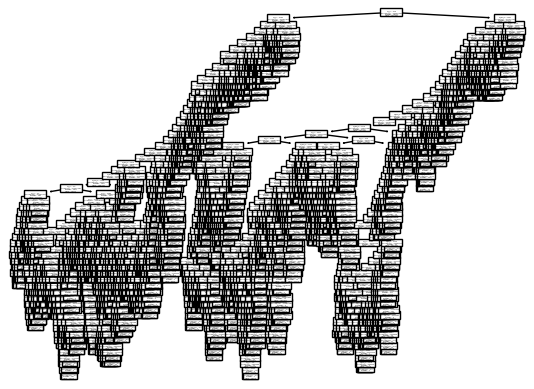

In [41]:
# le = LabelEncoder()
# k = le.fit_transform(df['song_id'])

# clf.predict()

tree.plot_tree(clf)

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from scipy.sparse import hstack, csr_matrix  
import numpy as np

tfidf = TfidfVectorizer(max_features=1000, stop_words='english') 
tekst_za_tfidf = df['artists_clean_text'].astype(str) + " " + df['terms_clean_text'].astype(str)
tfidf_matrica = tfidf.fit_transform(tekst_za_tfidf)

le = LabelEncoder()
y = le.fit_transform(df['song_id'])

x_numericki = df[['loudness', 'tempo', 'time_signature']].values
x_numericki_sparse = csr_matrix(x_numericki) 

x = hstack([x_numericki_sparse, tfidf_matrica], format='csr')

x, x_test, y, y_test = train_test_split(x, y, test_size=0.15, random_state=42)
x_train, x_val, y_train, y_val = train_test_split(x, y, test_size=0.1765, random_state=42)

clf = tree.DecisionTreeClassifier(max_depth=20)
clf = clf.fit(x_train, y_train)
y_pred = clf.predict(x_val)
hitovi = (y_pred == y_val).sum()
print(f" {(hitovi / len(y_val)) * 100:.2f}%")

Prava preciznost : 55.12%


In [ ]:
df.head()
jedinstvene_pesme = df[['song_id', 'artist_id']].drop_duplicates().reset_index(drop=True)

song_id_u_indeks = {}
for indeks, red in jedinstvene_pesme.iterrows():
    song_id_u_indeks[red['song_id']] = indeks

print(len(song_id_u_indeks))


2700


In [1]:
###ZA MASINU

In [ ]:
import numpy as np
import pandas as pd
from sklearn import tree
from sklearn.model_selection import train_test_split
import scipy.sparse as sp

izvor_interakcija = df

train_list = []
test_list = []

for user_id, group in izvor_interakcija.groupby("user_id"):
    n_samples = len(group)

    if n_samples >= 6:
        u_train, u_test = train_test_split(
           group, test_size=0.30, shuffle=True, random_state=42
        )
        train_list.append(u_train)
        test_list.append(u_test)

    elif 3 <= n_samples <= 5:
        group_shuffled = group.sample(frac=1, random_state=42)
        u_test = group_shuffled.iloc[[1]]
        u_train = group_shuffled.iloc[2:]
        train_list.append(u_train)
        test_list.append(u_test)

    elif n_samples == 2:
        u_train, u_test = train_test_split(
            group, test_size=0.50, shuffle=True, random_state=42
        )
        train_list.append(u_train)
        test_list.append(u_test)
    
    else:
        train_list.append(group)

df_train = pd.concat(train_list, ignore_index=True)
df_test = pd.concat(test_list, ignore_index=True)

print(f"train set  {df_train.shape[0]} interakcija")
print(f"test set   {df_test.shape[0]} interakcija\n")


def evaluiraj_maksimalni_dt(
    df_train,
    df_test,
    tfidf_matrica,
    song_id_u_indeks,
    df_pesme,
    top_n=15,
):
    ukupno_hitova = 0
    ukupno_preciznost = 0.0
    procenjeni_korisnici = 0

    test_users = df_test["user_id"].unique()
    tfidf_matrica = tfidf_matrica.tocsr()

    svi_indeksi_pesama = np.arange(tfidf_matrica.shape[0])
    
    for target_user_id in test_users:
        user_test_redovi = df_test[df_test["user_id"] == target_user_id]
        if user_test_redovi.empty:
            continue
            
        user_train = df_train[df_train["user_id"] == target_user_id]
        if user_train.empty:
            continue

        user_test_pesme = set(user_test_redovi["song_id"])

        pozitivni_indeksi = [song_id_u_indeks[s_id] for s_id in user_train["song_id"] if s_id in song_id_u_indeks]
        if not pozitivni_indeksi:
            continue
            
        skup_slusanih_id = set(user_train["song_id"])
        negativni_indeksi = []
        while len(negativni_indeksi) < len(pozitivni_indeksi) * 2:
            rand_idx = np.random.choice(svi_indeksi_pesama)
            s_id = df_pesme.iloc[rand_idx]["song_id"]
            if s_id not in skup_slusanih_id and rand_idx not in negativni_indeksi:
                negativni_indeksi.append(rand_idx)

        trenutni_indeksi_trening = pozitivni_indeksi + negativni_indeksi
        X_user_train = tfidf_matrica[trenutni_indeksi_trening]
        y_user_train = np.array([1] * len(pozitivni_indeksi) + [0] * len(negativni_indeksi))

        clf = tree.DecisionTreeClassifier(max_depth=10, random_state=42)
        clf.fit(X_user_train, y_user_train)

        broj_pesama = tfidf_matrica.shape[0]
        batch_size = 10000
        skorovi = np.zeros(broj_pesama)
        
        for start_idx in range(0, broj_pesama, batch_size):
            end_idx = min(start_idx + batch_size, broj_pesama)
            skorovi[start_idx:end_idx] = clf.predict_proba(tfidf_matrica[start_idx:end_idx])[:, 1]

        top_indeksi = np.argsort(skorovi)[::-1]

        preporuke_id = []
        vec_dodato = set()

        for idx in top_indeksi:
            s_id = df_pesme.iloc[idx]["song_id"]

            if s_id not in skup_slusanih_id and s_id not in vec_dodato:
                preporuke_id.append(s_id)
                vec_dodato.add(s_id)

            if len(preporuke_id) == top_n:
                break

        pogoci = [pesma for pesma in preporuke_id if pesma in user_test_pesme]
        broj_pogodaka = len(pogoci)

        if broj_pogodaka > 0:
            ukupno_hitova += 1
        ukupno_preciznost += broj_pogodaka / top_n
        procenjeni_korisnici += 1

    prosecan_hr = ukupno_hitova / procenjeni_korisnici if procenjeni_korisnici > 0 else 0
    prosecna_preciznost = ukupno_preciznost / procenjeni_korisnici if procenjeni_korisnici > 0 else 0
    
    print(f"evaluirano korisnika drvce {procenjeni_korisnici}")
    print(f"Hit Rate@{top_n}:     {prosecan_hr:.4f}")
    print(f"Precision@{top_n}:    {prosecna_preciznost:.4f}")

    return prosecan_hr, prosecna_preciznost

hr_full, prec_full = evaluiraj_maksimalni_dt(
    df_train=df_train,
    df_test=df_test,  
    tfidf_matrica=tfidf_matrica, 
    song_id_u_indeks=song_id_u_indeks,
    df_pesme=df,
    top_n=15,
)

Veličina train seta:       177089 interakcija
Veličina test seta:        86282 interakcija



MemoryError: Unable to allocate 2.07 MiB for an array with shape (271831,) and data type float64

### NEBITNO

In [ ]:
# import numpy as np
# import pandas as pd
# from sklearn import tree
# from sklearn.model_selection import train_test_split
# import scipy.sparse as sp

# # ==========================================
# # 1. PRVO KREIRAMO TRAIN I TEST SETOVE (da izbegneš NameError)
# # ==========================================
# izvor_interakcija = df_finalni

# train_list = []
# test_list = []

# for user_id, group in izvor_interakcija.groupby("user_id"):
#     n_samples = len(group)

#     if n_samples >= 6:
#         u_train, u_test = train_test_split(
#            group, test_size=0.30, shuffle=True, random_state=42
#         )
#         train_list.append(u_train)
#         test_list.append(u_test)

#     elif 3 <= n_samples <= 5:
#         group_shuffled = group.sample(frac=1, random_state=42)
#         u_test = group_shuffled.iloc[[1]]
#         u_train = group_shuffled.iloc[2:]
#         train_list.append(u_train)
#         test_list.append(u_test)

#     elif n_samples == 2:
#         u_train, u_test = train_test_split(
#             group, test_size=0.50, shuffle=True, random_state=42
#         )
#         train_list.append(u_train)
#         test_list.append(u_test)
    
#     else:
#         train_list.append(group)

# df_train = pd.concat(train_list, ignore_index=True)
# df_test = pd.concat(test_list, ignore_index=True)

# print(f"Veličina train seta:       {df_train.shape[0]} interakcija")
# print(f"Veličina test seta:        {df_test.shape[0]} interakcija\n")


# # ==========================================
# # 2. DEFINICIJA FUNKCIJE (sa ispravljenim tipfelerom)
# # ==========================================
# def evaluiraj_maksimalni_dt(
#     df_train,
#     df_test,
#     tfidf_matrica,
#     song_id_u_indeks,
#     df_pesme,
#     top_n=15,
# ):
#     ukupno_hitova = 0
#     ukupno_preciznost = 0.0
#     procenjeni_korisnici = 0

#     test_users = df_test["user_id"].unique()
#     tfidf_matrica = tfidf_matrica.tocsr()

#     svi_indeksi_pesama = np.arange(tfidf_matrica.shape[0])
    
#     for target_user_id in test_users:
#         user_test_redovi = df_test[df_test["user_id"] == target_user_id]
#         if user_test_redovi.empty:
#             continue
            
#         user_train = df_train[df_train["user_id"] == target_user_id]
#         if user_train.empty:
#             continue

#         user_test_pesme = set(user_test_redovi["song_id"])

#         # Pozitivni primeri
#         pozitivni_indeksi = [song_id_u_indeks[s_id] for s_id in user_train["song_id"] if s_id in song_id_u_indeks]
#         if not pozitivni_indeksi:
#             continue
            
#         # Negativni primeri
#         skup_slusanih_id = set(user_train["song_id"])
#         negativni_indeksi = []
#         while len(negativni_indeksi) < len(pozitivni_indeksi) * 2:
#             rand_idx = np.random.choice(svi_indeksi_pesama)
#             s_id = df_pesme.iloc[rand_idx]["song_id"]
#             if s_id not in skup_slusanih_id and rand_idx not in negativni_indeksi:
#                 negativni_indeksi.append(rand_idx)

#         # Spajanje (ovde je popravljen bag sa nazivom promenljive!)
#         trenutni_indeksi_trening = pozitivni_indeksi + negativni_indeksi
#         X_user_train = tfidf_matrica[trenutni_indeksi_trening]
#         y_user_train = np.array([1] * len(pozitivni_indeksi) + [0] * len(negativni_indeksi))

#         # Treniranje stabla (max_depth drži RAM pod kontrolom)
#         clf = tree.DecisionTreeClassifier(max_depth=10, random_state=42)
#         clf.fit(X_user_train, y_user_train)

#         # Predikcija
#         skorovi = clf.predict_proba(tfidf_matrica)[:, 1]
#         top_indeksi = np.argsort(skorovi)[::-1]

#         preporuke_id = []
#         vec_dodato = set()

#         for idx in top_indeksi:
#             s_id = df_pesme.iloc[idx]["song_id"]

#             if s_id not in skup_slusanih_id and s_id not in vec_dodato:
#                 preporuke_id.append(s_id)
#                 vec_dodato.add(s_id)

#             if len(preporuke_id) == top_n:
#                 break

#         # Evaluacija
#         pogoci = [pesma for pesma in preporuke_id if pesma in user_test_pesme]
#         broj_pogodaka = len(pogoci)

#         if broj_pogodaka > 0:
#             ukupno_hitova += 1
#         ukupno_preciznost += broj_pogodaka / top_n
#         procenjeni_korisnici += 1

#     prosecan_hr = ukupno_hitova / procenjeni_korisnici if procenjeni_korisnici > 0 else 0
#     prosecna_preciznost = ukupno_preciznost / procenjeni_korisnici if procenjeni_korisnici > 0 else 0
    
#     print(f"Evaluirano korisnika (Decision Tree): {procenjeni_korisnici}")
#     print(f"Hit Rate@{top_n}:     {prosecan_hr:.4f}")
#     print(f"Precision@{top_n}:    {prosecna_preciznost:.4f}")

#     return prosecan_hr, prosecna_preciznost


# # ==========================================
# # 3. POKRETANJE EVALUACIJE
# # ==========================================
# # PAŽNJA: Proveri da li ti se matrica zove tfidf_matrica ili tfidf_matrix i promeni ovde ako treba
# hr_full, prec_full = evaluiraj_maksimalni_dt(
#     df_train=df_train,
#     df_test=df_test,  
#     tfidf_matrica=tfidf_matrica, 
#     song_id_u_indeks=song_id_u_indeks,
#     df_pesme=df_finalni,
#     top_n=15,
# )

## JACCARD SIM

In [ ]:
# import numpy as np
# import pandas as pd
# from sklearn.feature_extraction.text import CountVectorizer
# from sklearn.metrics import pairwise_distances  
# def evaluiraj_ugradjeni_jaccard(
#     df_train,
#     df_test,
#     tfidf_matrica,       
#     song_id_u_indeks,    
#     df_pesme,
#     top_n=15,
# ):
#     ukupno_hitova = 0
#     ukupno_preciznost = 0.0
#     procenjeni_korisnici = 0

#     test_users = df_test["user_id"].unique()

#     tekstovi = (df_pesme['artists_clean_text'].fillna('') + " " + df_pesme['terms_clean_text'].fillna(''))
    
#     vectorizer = CountVectorizer(binary=True)
#     X_pesme = vectorizer.fit_transform(tekstovi) 
    
#     brzi_maping = {s_id: i for i, s_id in enumerate(df_pesme['song_id'])}

#     print("Započinjem evaluaciju uz sklearn ugrađenu funkciju...")
#     for target_user_id in test_users:
#         user_test_redovi = df_test[df_test["user_id"] == target_user_id]
#         if user_test_redovi.empty:
#             continue
            
#         user_train = df_train[df_train["user_id"] == target_user_id]
#         if user_train.empty:
#             continue

#         user_test_pesme = set(user_test_redovi["song_id"])
#         skup_slusanih_id = set(user_train["song_id"])

#         user_pesme_indeksi = [brzi_maping[s_id] for s_id in user_train["song_id"] if s_id in brzi_maping]
#         if not user_pesme_indeksi:
#             continue

#         profil_korisnika = np.asarray(X_pesme[user_pesme_indeksi].sum(axis=0) > 0).astype(int)
        
#         jaccard_distanca = pairwise_distances(X_pesme, profil_korisnika.reshape(1, -1), metric="jaccard").flatten()        skorovi = 1.0 - jaccard_distanca

#         top_indeksi = np.argsort(skorovi)[::-1]

#         preporuke_id = []
#         vec_dodato = set()

#         for idx in top_indeksi:
#             s_id = df_pesme.iloc[idx]["song_id"]
#             if s_id not in skup_slusanih_id and s_id not in vec_dodato:
#                 preporuke_id.append(s_id)
#                 vec_dodato.add(s_id)
#             if len(preporuke_id) == top_n:
#                 break

#         pogoci = [pesma for pesma in preporuke_id if pesma in user_test_pesme]
#         broj_pogodaka = len(pogoci)

#         if broj_pogodaka > 0:
#             ukupno_hitova += 1
#         ukupno_preciznost += broj_pogodaka / top_n
#         procenjeni_korisnici += 1

#     prosecan_hr = ukupno_hitova / procenjeni_korisnici if procenjeni_korisnici > 0 else 0
#     prosecna_preciznost = ukupno_preciznost / procenjeni_korisnici if procenjeni_korisnici > 0 else 0
    
#     print(f"\nevaluirano korisnika dzered {procenjeni_korisnici}")
#     print(f"Hit Rate@{top_n}:     {prosecan_hr:.4f}")
#     print(f"Precision@{top_n}:    {prosecna_preciznost:.4f}")

#     return prosecan_hr, prosecna_preciznost

# t_matrica = tfidf_matrica if 'tfidf_matrica' in locals() else None
# s_maping = song_id_u_indeks if 'song_id_u_indeks' in locals() else None

# hr_full, prec_full = evaluiraj_maksimalni_jaccard(
#     df_train=df_train,
#     df_test=df_test,  
#     tfidf_matrica=t_matrica, 
#     song_id_u_indeks=s_maping,
#     df_pesme=df_jedinstvene_pesme, 
#     top_n=15,
# )

Pripremam skupove reči za sve pesme...
Započinjem evaluaciju korisnika...

Evaluirano korisnika (Jaccard Similarity): 25781
Hit Rate@15:     0.2196
Precision@15:    0.0163


In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

izvor_interakcija = df  

train_list = []
test_list = []

for user_id, group in izvor_interakcija.groupby("user_id"):
    n_samples = len(group)

    if n_samples >= 6:
        u_train, u_test = train_test_split(
           group, test_size=0.30, shuffle=True, random_state=42
        )
        train_list.append(u_train)
        test_list.append(u_test)

    elif 3 <= n_samples <= 5:
        group_shuffled = group.sample(frac=1, random_state=42)
        u_test = group_shuffled.iloc[[1]]
        u_train = group_shuffled.iloc[2:]
        train_list.append(u_train)
        test_list.append(u_test)

    elif n_samples == 2:
        u_train, u_test = train_test_split(
            group, test_size=0.50, shuffle=True, random_state=42
        )
        train_list.append(u_train)
        test_list.append(u_test)
    
    else:
        train_list.append(group)

df_train = pd.concat(train_list, ignore_index=True)
df_test = pd.concat(test_list, ignore_index=True)

print(f"Veličina train seta:       {df_train.shape[0]} interakcija")
print(f"Veličina test seta:        {df_test.shape[0]} interakcija")

df_jedinstvene_pesme = df[['song_id', 'artists_clean_text', 'terms_clean_text']].drop_duplicates(subset=['song_id']).reset_index(drop=True)
print(f"Ukupno jedinstvenih pesama za preporuku: {df_jedinstvene_pesme.shape[0]}\n")



def evaluiraj_maksimalni_jaccard(
    df_train,
    df_test,
    tfidf_matrica,      
    song_id_u_indeks,    
    df_pesme,
    top_n=15,
):
    ukupno_hitova = 0
    ukupno_preciznost = 0.0
    procenjeni_korisnici = 0

    test_users = df_test["user_id"].unique()

    print("Pripremam skupove reči za sve pesme...")
    pesme_skupovi_reci = []
    for _, red in df_pesme.iterrows():
        tekst = str(red['artists_clean_text']) + " " + str(red['terms_clean_text'])
        pesme_skupovi_reci.append(set(tekst.split()))
    
    broj_pesama = len(pesme_skupovi_reci)
    brzi_maping = {red['song_id']: i for i, red in df_pesme.iterrows()}

    print("Započinjem evaluaciju korisnika...")
    for target_user_id in test_users:
        user_test_redovi = df_test[df_test["user_id"] == target_user_id]
        if user_test_redovi.empty:
            continue
            
        user_train = df_train[df_train["user_id"] == target_user_id]
        if user_train.empty:
            continue

        user_test_pesme = set(user_test_redovi["song_id"])
        skup_slusanih_id = set(user_train["song_id"])

        # Profil korisnika
        profil_korisnika_skup = set()
        for s_id in user_train["song_id"]:
            if s_id in brzi_maping:
                idx_p = brzi_maping[s_id]
                profil_korisnika_skup.update(pesme_skupovi_reci[idx_p])

        if not profil_korisnika_skup:
            continue

        # Jaccard
        skorovi = np.zeros(broj_pesama)
        for idx_p in range(broj_pesama):
            skup_pesme = pesme_skupovi_reci[idx_p]
            presek = 2*len(profil_korisnika_skup.intersection(skup_pesme))
            unija = len(profil_korisnika_skup)+len(skup_pesme)
            skorovi[idx_p] = presek / unija if unija > 0 else 0

        top_indeksi = np.argsort(skorovi)[::-1]

        preporuke_id = []
        vec_dodato = set()

        for idx in top_indeksi:
            s_id = df_pesme.iloc[idx]["song_id"]
            if s_id not in skup_slusanih_id and s_id not in vec_dodato:
                preporuke_id.append(s_id)
                vec_dodato.add(s_id)
            if len(preporuke_id) == top_n:
                break

        # Metrike
        pogoci = [pesma for pesma in preporuke_id if pesma in user_test_pesme]
        broj_pogodaka = len(pogoci)

        if broj_pogodaka > 0:
            ukupno_hitova += 1
        ukupno_preciznost += broj_pogodaka / top_n
        procenjeni_korisnici += 1

    prosecan_hr = ukupno_hitova / procenjeni_korisnici if procenjeni_korisnici > 0 else 0
    prosecna_preciznost = ukupno_preciznost / procenjeni_korisnici if procenjeni_korisnici > 0 else 0
    
    print(f"\nEvaluirano korisnika (Jaccard Similarity): {procenjeni_korisnici}")
    print(f"Hit Rate@{top_n}:     {prosecan_hr:.4f}")
    print(f"Precision@{top_n}:    {prosecna_preciznost:.4f}")

    return prosecan_hr, prosecna_preciznost


t_matrica = tfidf_matrica if 'tfidf_matrica' in locals() else None
s_maping = song_id_u_indeks if 'song_id_u_indeks' in locals() else None

hr_full, prec_full = evaluiraj_maksimalni_jaccard(
    df_train=df_train,
    df_test=df_test,  
    tfidf_matrica=t_matrica, 
    song_id_u_indeks=s_maping,
    df_pesme=df_jedinstvene_pesme, 
    top_n=15,
)

NameError: name 'df_train' is not defined